In [1]:
import matplotlib.pyplot as plt

In [2]:
from SabinasStarryProcess import *

from jaxoplanet.starry.surface import Surface
from jaxoplanet.starry.visualization import show_surface

In [3]:
log_factorial(5)

W0623 22:26:53.615056 5091550 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Array(4.7874928, dtype=float32, weak_type=True)

In [4]:
clmmpi(5,-4,0,7)

0.0

In [5]:
alpha = 5*jnp.sqrt(3)
beta = 10-alpha

In [6]:
lmax = 5
r = 0.1
c = 0.5
n = 1

In [7]:
er = compute_radius_moment(lmax, r, c)

In [8]:
er.data

{(0, 0): Array(-0.00669073, dtype=float32),
 (1, -1): Array(0., dtype=float32),
 (1, 0): Array(-0.00997682, dtype=float32),
 (1, 1): Array(0., dtype=float32),
 (2, -2): Array(0., dtype=float32),
 (2, -1): Array(0., dtype=float32),
 (2, 0): Array(-0.01648756, dtype=float32),
 (2, 1): Array(0., dtype=float32),
 (2, 2): Array(0., dtype=float32),
 (3, -3): Array(0., dtype=float32),
 (3, -2): Array(0., dtype=float32),
 (3, -1): Array(0., dtype=float32),
 (3, 0): Array(-0.01700271, dtype=float32),
 (3, 1): Array(0., dtype=float32),
 (3, 2): Array(0., dtype=float32),
 (3, 3): Array(0., dtype=float32),
 (4, -4): Array(0., dtype=float32),
 (4, -3): Array(0., dtype=float32),
 (4, -2): Array(0., dtype=float32),
 (4, -1): Array(0., dtype=float32),
 (4, 0): Array(-0.0360939, dtype=float32),
 (4, 1): Array(0., dtype=float32),
 (4, 2): Array(0., dtype=float32),
 (4, 3): Array(0., dtype=float32),
 (4, 4): Array(0., dtype=float32),
 (5, -5): Array(0., dtype=float32),
 (5, -4): Array(0., dtype=float32),

In [10]:
mean_ylm = compute_mean(alpha, beta, r, c, n, lmax)

In [11]:
mean_ylm

Array([-1.0509750e-02,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00, -1.8235142e-03,  0.0000000e+00,
       -3.1584629e-03,  0.0000000e+00,  4.9325910e-16,  0.0000000e+00,
       -1.0971886e-09,  0.0000000e+00,  1.2930491e-09,  0.0000000e+00,
        1.1560762e-16,  0.0000000e+00, -8.6320339e-16,  0.0000000e+00,
        3.2201670e-03,  0.0000000e+00,  4.8003276e-03,  0.0000000e+00,
        6.3502467e-03,  0.0000000e+00, -5.9807667e-15,  0.0000000e+00,
        3.3911563e-15,  0.0000000e+00, -2.8526904e-08,  0.0000000e+00,
        1.9395738e-09,  0.0000000e+00, -8.0169054e-09,  0.0000000e+00],      dtype=float32)

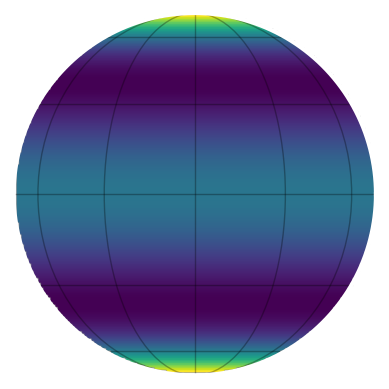

In [12]:
show_surface(mean_ylm)

In [13]:
cov_ylm = compute_covariance(alpha, beta, r, c, n, lmax)

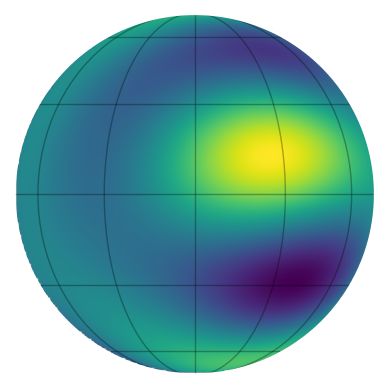

In [14]:
show_surface(jnp.diag(cov_ylm))

Text(0.5, 1.0, 'jax-o-starryprocess')

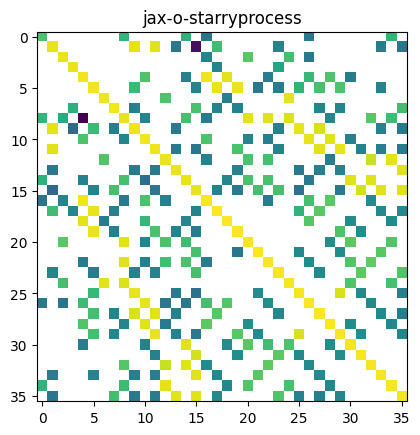

In [15]:
plt.imshow(jnp.log10(cov_ylm))
plt.title('jax-o-starryprocess')

In [16]:
jnp.log10(cov_ylm)

Array([[-10.201802 ,        -inf,        -inf, ...,        -inf,
        -11.844035 ,        -inf],
       [       -inf,  -4.230559 ,        -inf, ..., -17.466078 ,
               -inf, -18.329613 ],
       [       -inf,        -inf,  -4.0296817, ...,        -inf,
                nan,        -inf],
       ...,
       [       -inf, -17.531258 ,        -inf, ...,  -3.6020296,
               -inf,         nan],
       [-11.844035 ,        -inf,         nan, ...,        -inf,
         -3.6203747,        -inf],
       [       -inf, -18.27162  ,        -inf, ...,         nan,
               -inf,  -3.6753461]], dtype=float32)

In [17]:
cov_ylm

Array([[ 6.2834467e-11,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  1.4320718e-12,  0.0000000e+00],
       [ 0.0000000e+00,  5.8808673e-05,  0.0000000e+00, ...,
         3.4191908e-18,  0.0000000e+00,  4.6815310e-19],
       [ 0.0000000e+00,  0.0000000e+00,  9.3393879e-05, ...,
         0.0000000e+00, -4.7782116e-05,  0.0000000e+00],
       ...,
       [ 0.0000000e+00,  2.9426777e-18,  0.0000000e+00, ...,
         2.5001759e-04,  0.0000000e+00, -2.1239332e-05],
       [ 1.4320718e-12,  0.0000000e+00, -4.7782123e-05, ...,
         0.0000000e+00,  2.3967633e-04,  0.0000000e+00],
       [ 0.0000000e+00,  5.3503200e-19,  0.0000000e+00, ...,
        -2.1239339e-05,  0.0000000e+00,  2.1118055e-04]], dtype=float32)

In [17]:
cov_sp = np.load('sp_cov_c.npy')
mean_sp = np.load('sp_mean_c.npy')

In [20]:
cov_ylm - cov_sp

Array([[ 1.6177531e-06,  5.3144622e-19, -1.6573390e-18, ...,
        -6.5064256e-20, -7.8167653e-11, -2.5937560e-20],
       [ 5.3144622e-19, -5.9117156e-11,  4.6921109e-21, ...,
         7.2517826e-20,  3.5892568e-22,  1.7176958e-20],
       [-1.6573390e-18,  4.6921109e-21, -1.1459633e-10, ...,
        -1.5643155e-19,  9.4360075e-12, -2.7114389e-20],
       ...,
       [-6.5064256e-20,  7.1472832e-20, -1.5643155e-19, ...,
         1.7053026e-13, -8.6170358e-20, -8.2422957e-13],
       [-7.8167653e-11,  3.5892568e-22,  9.4360075e-12, ...,
        -8.6170358e-20,  5.8548721e-12, -6.8916407e-21],
       [-2.5937560e-20,  1.9266920e-20, -2.7114389e-20, ...,
        -8.4554586e-13, -6.8916407e-21,  4.0927262e-12]], dtype=float32)

In [21]:
mean_ylm - mean_sp

Array([-3.9339066e-06,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  9.0803951e-09,  0.0000000e+00,
        1.3969839e-09,  0.0000000e+00,  1.0790043e-16,  0.0000000e+00,
       -2.2858096e-10,  0.0000000e+00,  2.5860983e-10,  0.0000000e+00,
        1.2524155e-17,  0.0000000e+00, -9.2486078e-17,  0.0000000e+00,
       -1.8626451e-09,  0.0000000e+00, -4.3073669e-09,  0.0000000e+00,
       -4.4819899e-09,  0.0000000e+00, -3.0443336e-16,  0.0000000e+00,
        1.5703366e-16,  0.0000000e+00, -1.2286226e-09,  0.0000000e+00,
        1.3738648e-10,  0.0000000e+00, -3.7175160e-10,  0.0000000e+00],      dtype=float32)